In [42]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from thermo import ChemicalConstantsPackage, PRMIX, CEOSGas, CEOSLiquid, FlashVL
from thermo.interaction_parameters import IPDB

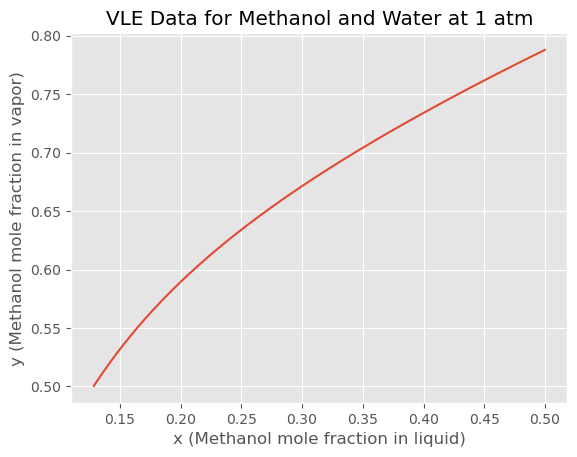

In [49]:
# Chemical IDs for methanol and water
ids = ['methanol', 'water']


constants, properties = ChemicalConstantsPackage.from_IDs(ids)
kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')

# Peng-Robinson EOS parameters
eos_kwargs = {'Pcs': constants.Pcs, 'Tcs': constants.Tcs, 'omegas': constants.omegas, 'kijs': kijs}
gas = CEOSGas(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)
liquid = CEOSLiquid(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)

flasher = FlashVL(constants, properties, gas=gas, liquid=liquid)

T_range = np.linspace(330, 380, 10**3)
P = 101325  # 1 atm in Pa

x_data = []
y_data = []

# Perform flash calculations at different temperatures
for T in T_range:
    state = flasher.flash(T=T, P=P, zs=[0.5, 0.5])  # assuming 50/50 mixture as a starting point
    if state.VF == 0:
        # print(f"Pure liquid at T={T} K")
        pass
    elif state.VF == 1:
        # print(f"Pure vapor at T={T} K")
        pass
    else:
        x_data.append(state.liquid_zs[0])  # Methanol composition in liquid
        y_data.append(state.gas.zs[0])      # Methanol composition in vapor


fig, ax = plt.subplots()
ax.plot(x_data, y_data, '-')
ax.set_title('VLE Data for Methanol and Water at 1 atm')
ax.set_xlabel('x (Methanol mole fraction in liquid)')
ax.set_ylabel('y (Methanol mole fraction in vapor)')
plt.show()

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from thermo import ChemicalConstantsPackage, PRMIX, CEOSGas, CEOSLiquid, FlashVL, NRTL, TDependentProperty
from thermo.interaction_parameters import IPDB

# Chemical IDs for methanol and water
ids = ['methanol', 'water']

# Get constant properties and interaction parameters
constants, properties = ChemicalConstantsPackage.from_IDs(ids)
kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')

# Peng-Robinson EOS parameters
eos_kwargs = {'Pcs': constants.Pcs, 'Tcs': constants.Tcs, 'omegas': constants.omegas, 'kijs': kijs}
gas = CEOSGas(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)
liquid = CEOSLiquid(PRMIX, eos_kwargs=eos_kwargs, HeatCapacityGases=properties.HeatCapacityGases)

# NRTL activity model
nrtl = NRTL(T=298.15, xs=[0.5, 0.5])

# Temperature and pressure range
T_range = np.linspace(330, 380, 50)
P = 101325  # 1 atm in Pa

x_data = np.linspace(0.01, 0.99, 100)
y_data = []

for x in x_data:
    nrtl.xs = [x, 1 - x]
    nrtl.T = 365  # Example temperature
    gamma = nrtl.gammas()

    Psat_methanol = properties.VaporPressures 
    Psat_water = properties.VaporPressures 

    y_methanol = x * gamma[0] * Psat_methanol / P
    y_data.append(y_methanol)

# Plotting
plt.style.use('ggplot')
fig, ax = plt.subplots()
ax.plot(x_data, y_data, '-')
ax.set_title('VLE Data for Methanol and Water at 1 atm')
ax.set_xlabel('x (Methanol mole fraction in liquid)')
ax.set_ylabel('y (Methanol mole fraction in vapor)')
plt.show()


TypeError: can't multiply sequence by non-int of type 'numpy.float64'